<a href="https://colab.research.google.com/github/milicak/Data_Analysis_Course/blob/main/08_Compute_EOF_ElNino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install basemap
!pip install eofs
!pip install cartopy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 82.6 MB/s eta 0:00:00


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
# Corrected URL pointing to the actual NetCDF file
# url = 'https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.oisst.mon.mean.1982.nc'
url = 'https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.mnmean.nc'
!wget $url


--2026-04-13 15:39:25--  https://psl.noaa.gov/thredds/fileServer/Datasets/noaa.oisst.v2/sst.mnmean.nc
Resolving psl.noaa.gov (psl.noaa.gov)... 140.172.38.12
Connecting to psl.noaa.gov (psl.noaa.gov)|140.172.38.12|:443... connected.
HTTP request sent, awaiting response... 429 Too Many Requests
2026-04-13 15:39:26 ERROR 429: Too Many Requests.



In [ ]:
# go to https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html and download sst.mnmean.nc
# from Sea Surface Temperature 2	Sea Surface Temperature	Long Term Mean	Surface	Monthly

In [7]:
from google.colab import files
uploaded = files.upload()

Saving sst.mnmean.nc to sst.mnmean.nc


In [2]:
df = xr.open_dataset('sst.mnmean.nc')
df

<xarray.Dataset> Size: 128MB
Dimensions:    (time: 494, lat: 180, lon: 360, nbnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-12-01 1982-01-01 ... 2023-01-01
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: nbnds
Data variables:
    sst        (time, lat, lon) float32 128MB ...
    time_bnds  (time, nbnds) datetime64[ns] 8kB ...
Attributes:
    title:          NOAA Optimum Interpolation (OI) SST V2
    Conventions:    CF-1.0
    history:        Wed Apr  6 13:47:45 2005: ncks -d time,0,278 SAVEs/sst.mn...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Optimum Interpolation (OI) SST V2
    source_url:     http://www.emc.ncep.noaa.gov/research/cmb/sst_analysis/

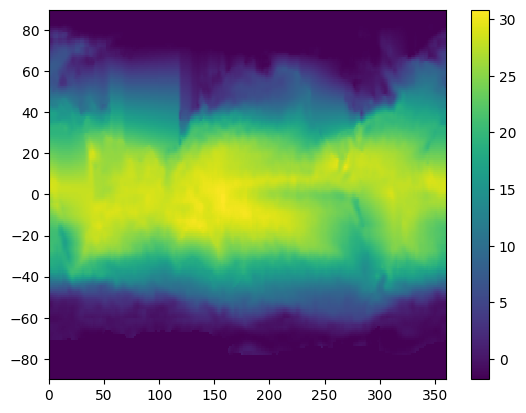

In [3]:
plt.pcolormesh(df.lon,df.lat,df.sst[0,:,:])
plt.colorbar()
plt.show()

In [4]:
df = df.sel(time=slice('1982-01-01','2022-12-31'))
df

<xarray.Dataset> Size: 128MB
Dimensions:    (time: 492, lat: 180, lon: 360, nbnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1982-01-01 1982-02-01 ... 2022-12-01
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: nbnds
Data variables:
    sst        (time, lat, lon) float32 128MB ...
    time_bnds  (time, nbnds) datetime64[ns] 8kB ...
Attributes:
    title:          NOAA Optimum Interpolation (OI) SST V2
    Conventions:    CF-1.0
    history:        Wed Apr  6 13:47:45 2005: ncks -d time,0,278 SAVEs/sst.mn...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Optimum Interpolation (OI) SST V2
    source_url:     http://www.emc.ncep.noaa.gov/research/cmb/sst_analysis/

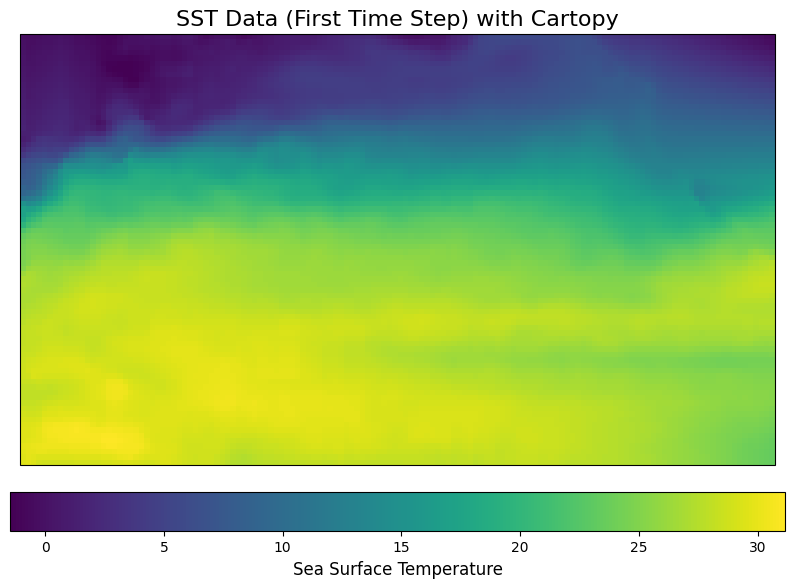

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

df2 = df.sel(lon=slice(120,260),lat=slice(60,-20))

plt.figure(figsize=(10, 7)) # Set a good figure size for the map
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190)) # Use PlateCarree projection

# Plot the SST data using pcolormesh
fill = ax.pcolormesh(df2.lon, df2.lat, df2.sst[0,:,:],
                     transform=ccrs.PlateCarree()) # Plotting the first time step

ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='k') # Add land features
#ax.add_feature(cfeature.COASTLINES) # Add coastlines
ax.set_title('SST Data (First Time Step) with Cartopy', fontsize=16)

# Add colorbar
cb = plt.colorbar(fill, orientation='horizontal', pad=0.05, ax=ax)
cb.set_label('Sea Surface Temperature', fontsize=12)

plt.show()

In [6]:
df2

<xarray.Dataset> Size: 22MB
Dimensions:    (time: 492, lat: 80, lon: 140, nbnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1982-01-01 1982-02-01 ... 2022-12-01
  * lat        (lat) float32 320B 59.5 58.5 57.5 56.5 ... -17.5 -18.5 -19.5
  * lon        (lon) float32 560B 120.5 121.5 122.5 123.5 ... 257.5 258.5 259.5
Dimensions without coordinates: nbnds
Data variables:
    sst        (time, lat, lon) float32 22MB ...
    time_bnds  (time, nbnds) datetime64[ns] 8kB ...
Attributes:
    title:          NOAA Optimum Interpolation (OI) SST V2
    Conventions:    CF-1.0
    history:        Wed Apr  6 13:47:45 2005: ncks -d time,0,278 SAVEs/sst.mn...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Optimum Interpolation (OI) SST V2
    source_url:     http://www.emc.ncep.noaa.gov/research/cmb/sst_analysis/

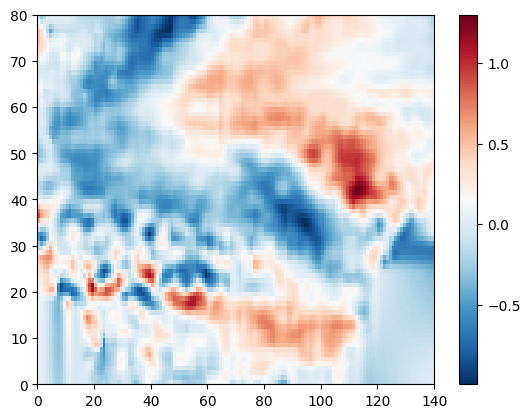

In [7]:
ds_season = df2.where(df2['time.season'] == 'DJF').groupby('time.year').mean('time')
# Select the 'sst' variable before performing the subtraction
sst = ds_season['sst'] - ds_season.sst.mean('year')
plt.pcolormesh(sst[12,:,:],cmap='RdBu_r');plt.colorbar()

In [42]:
# rename time variable to be consistent with the EOFS package
sst = sst.rename({'year':'time'})

In [43]:
from eofs.xarray import Eof

In [44]:
coslat = np.cos(np.deg2rad(sst.coords['lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(-sst, weights=wgts)


In [45]:
# Retrieve the leading EOF, expressed as the correlation between the leading
# PC time series and the input SST anomalies at each grid point, and the
# leading PC time series itself.
eof1 = solver.eofsAsCorrelation(neofs=1)
pc1 = solver.pcs(npcs=1, pcscaling=1)
varfrac1 = solver.varianceFraction()
lambdas1 = solver.eigenvalues()

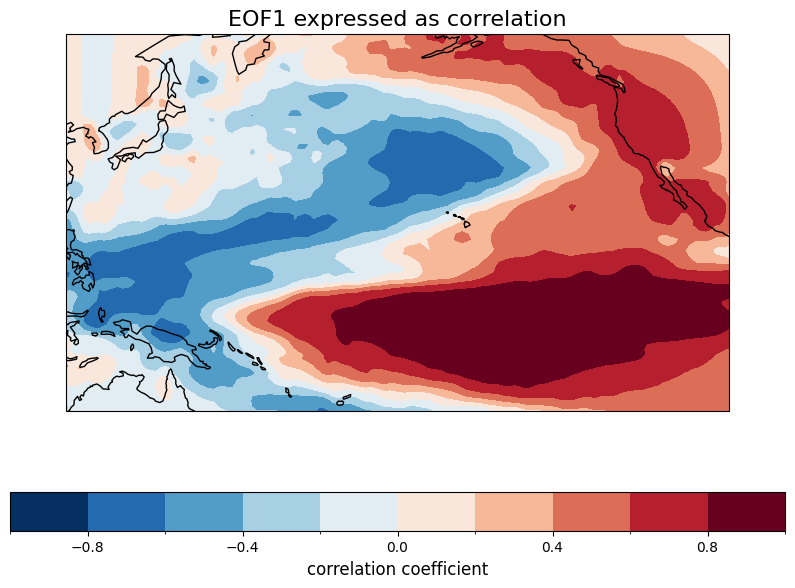

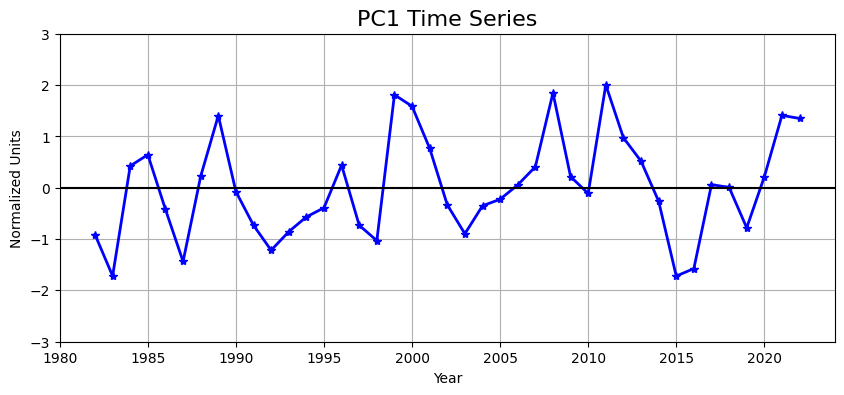

In [51]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

nino34_lat_slice = slice(5, -5) # 5S to 5N
nino34_lon_slice = slice(190, 240) # 170W to 120W (360 - 170 = 190; 360 - 120 = 240)

# Plot the leading EOF expressed as correlation in the Pacific domain.
clevs = np.linspace(-1, 1, 11)

plt.figure(figsize=(10, 7)) # Set a good figure size for the map
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = eof1[0].plot.contourf(ax=ax, levels=clevs, cmap=plt.cm.RdBu_r,
                             add_colorbar=False, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='k') # Changed land color to lightgray
ax.coastlines()
cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('correlation coefficient', fontsize=12)
ax.set_title('EOF1 expressed as correlation', fontsize=16)

# Plot the leading PC time series.
plt.figure(figsize=(10, 4)) # Set a good figure size for the PC plot
pc1[:, 0].plot(color='b',marker='*', linewidth=2)
plt.grid()
ax = plt.gca()
ax.axhline(0, color='k')
ax.set_ylim(-3, 3)
ax.set_xlabel('Year')
ax.set_ylabel('Normalized Units')
ax.set_title('PC1 Time Series', fontsize=16)

plt.show()

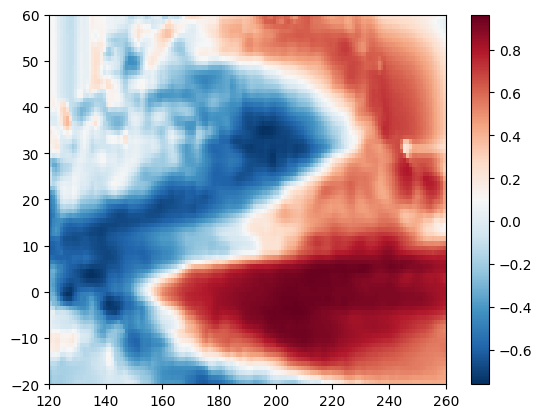

In [13]:
plt.pcolormesh(sst.lon,sst.lat,eof1[0,:,:],cmap='RdBu_r');plt.colorbar()

(4.858054766232185e-16, 0.3981826400756836)

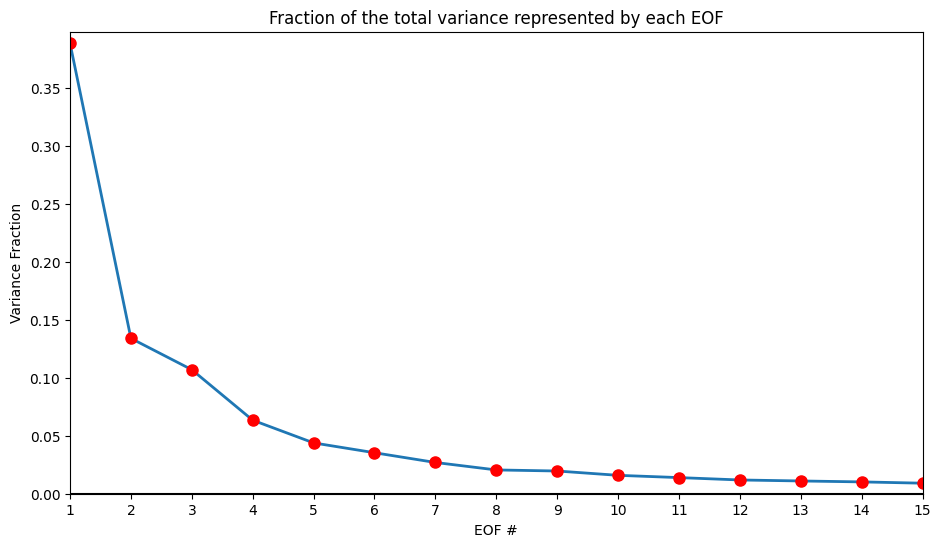

In [14]:
plt.figure(figsize=(11,6))
eof_num = range(1, 16)
plt.plot(eof_num, varfrac1[0:15], linewidth=2)
plt.plot(eof_num, varfrac1[0:15], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16))
plt.title('Fraction of the total variance represented by each EOF')
plt.xlabel('EOF #')
plt.ylabel('Variance Fraction')
plt.xlim(1, 15)
plt.ylim(np.min(varfrac1), np.max(varfrac1)+0.01)

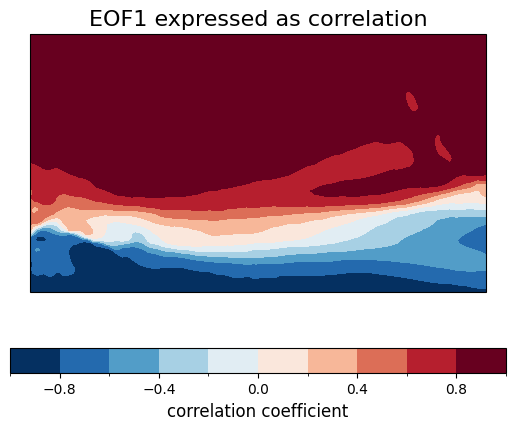

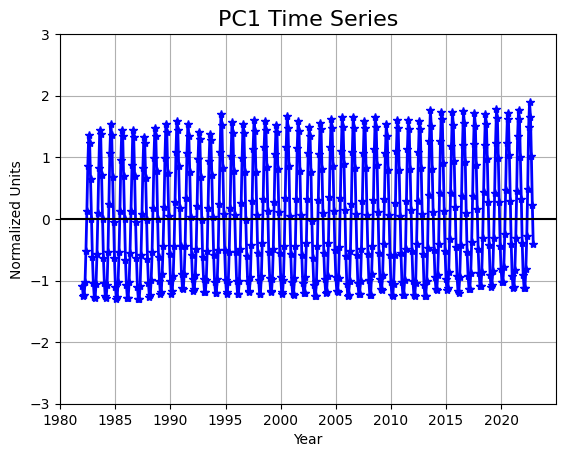

In [40]:
#ds_season = df2.where(df2['time.season'] == 'DJF').groupby('time.year').mean('time')
ds_season = df2
sst = ds_season
# convert to data_array
sst = sst.sst
coslat = np.cos(np.deg2rad(sst.coords['lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(sst, weights=wgts)
# Retrieve the leading EOF, expressed as the correlation between the leading
# PC time series and the input SST anomalies at each grid point, and the
# leading PC time series itself.
eof1 = solver.eofsAsCorrelation(neofs=2)
pc1 = solver.pcs(npcs=2, pcscaling=1)
varfrac1 = solver.varianceFraction()
lambdas1 = solver.eigenvalues()

# Plot the leading EOF expressed as correlation in the Pacific domain.
clevs = np.linspace(-1, 1, 11)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = eof1[0].plot.contourf(ax=ax, levels=clevs, cmap=plt.cm.RdBu_r,
                             add_colorbar=False, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='w', edgecolor='k')
cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('correlation coefficient', fontsize=12)
ax.set_title('EOF1 expressed as correlation', fontsize=16)

# Plot the leading PC time series.
plt.figure()
pc1[:, 0].plot(color='b',marker='*', linewidth=2)
plt.grid()
ax = plt.gca()
ax.axhline(0, color='k')
ax.set_ylim(-3, 3)
ax.set_xlabel('Year')
ax.set_ylabel('Normalized Units')
ax.set_title('PC1 Time Series', fontsize=16)

plt.show()

(4.940914344331304e-11, 0.8861836886405945)

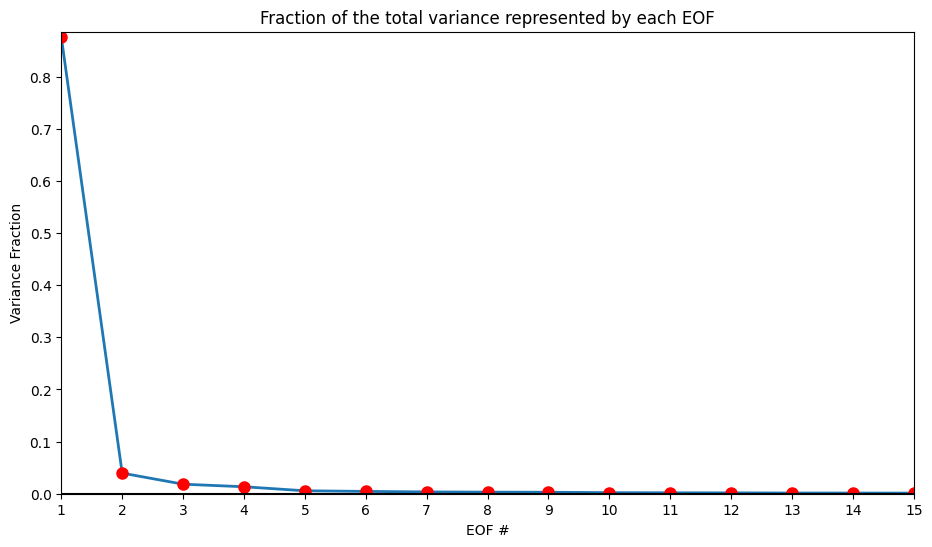

In [43]:
plt.figure(figsize=(11,6))
eof_num = range(1, 16)
plt.plot(eof_num, varfrac1[0:15], linewidth=2)
plt.plot(eof_num, varfrac1[0:15], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16))
plt.title('Fraction of the total variance represented by each EOF')
plt.xlabel('EOF #')
plt.ylabel('Variance Fraction')
plt.xlim(1, 15)
plt.ylim(np.min(varfrac1), np.max(varfrac1)+0.01)

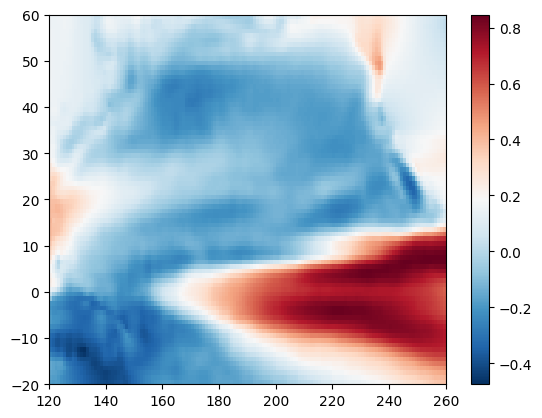

In [ ]:
plt.pcolormesh(sst.lon,sst.lat,eof1[1,:,:],cmap='RdBu_r');plt.colorbar()

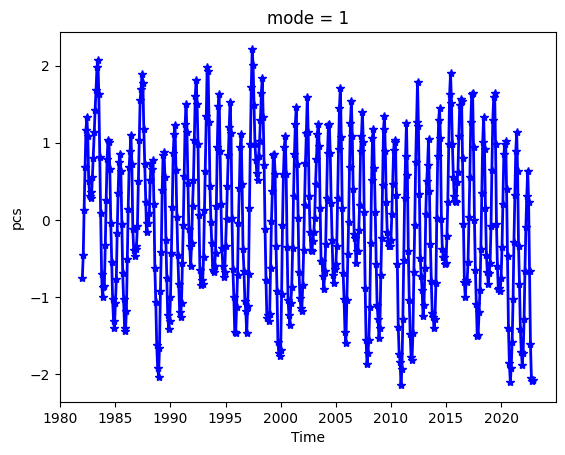

In [ ]:
pc1[:, 1].plot(color='b',marker='*', linewidth=2)

In [32]:
# Define Nino3.4 region boundaries
nino34_lat_slice = slice(5, -5) # 5S to 5N
nino34_lon_slice = slice(190, 240) # 170W to 120W (360 - 170 = 190; 360 - 120 = 240)

# Select the SST data for the Nino3.4 region
ds_season = df2.where(df2['time.season'] == 'DJF').groupby('time.year').mean('time')
# Select the 'sst' variable before performing the subtraction
sst = ds_season['sst']- ds_season.sst.mean('year')

nino34_sst = sst.sel(lat=nino34_lat_slice, lon=nino34_lon_slice)
# rename time variable to be consistent with the EOFS package
nino34_sst = nino34_sst.rename({'year':'time'})

coslat = np.cos(np.deg2rad(nino34_sst.coords['lat'].values))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(nino34_sst, weights=wgts)
# Retrieve the leading EOF, expressed as the correlation between the leading
# PC time series and the input SST anomalies at each grid point, and the
# leading PC time series itself.
eof1 = solver.eofsAsCorrelation(neofs=1)
pc1 = solver.pcs(npcs=1, pcscaling=1)
varfrac1 = solver.varianceFraction()
lambdas1 = solver.eigenvalues()

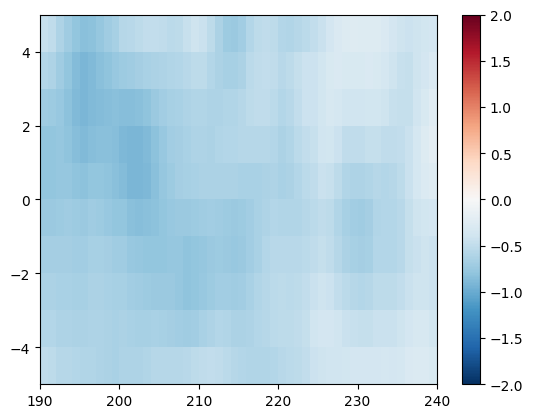

In [39]:
plt.pcolormesh(nino34_sst.lon,nino34_sst.lat,nino34_sst[19,:,:],cmap='RdBu_r',vmin=-2,vmax=2);plt.colorbar()

Text(0.5, 1.0, 'PC1 Time Series')

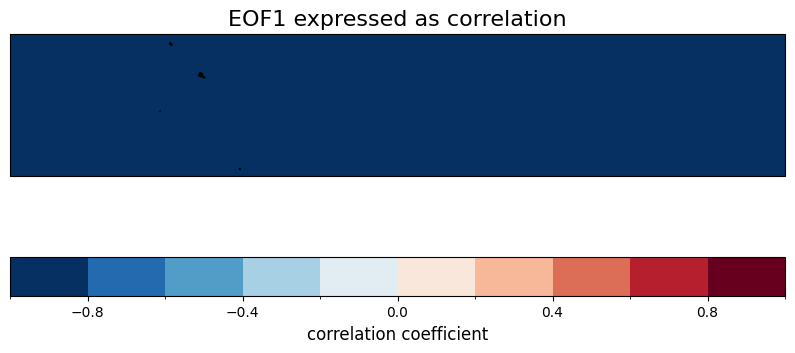

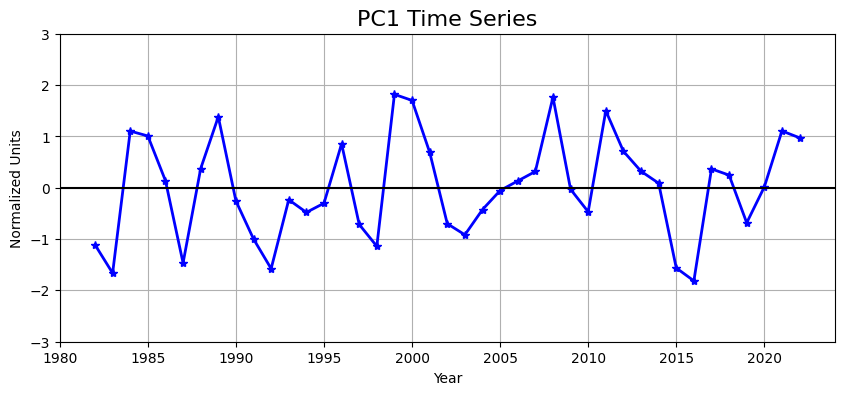

In [28]:
# Plot the leading EOF expressed as correlation in the Pacific domain.
clevs = np.linspace(-1, 1, 11)

plt.figure(figsize=(10, 7)) # Set a good figure size for the map
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=190))
fill = eof1[0].plot.contourf(ax=ax, levels=clevs, cmap=plt.cm.RdBu_r,
                             add_colorbar=False, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='k') # Changed land color to lightgray
ax.coastlines()
cb = plt.colorbar(fill, orientation='horizontal')
cb.set_label('correlation coefficient', fontsize=12)
ax.set_title('EOF1 expressed as correlation', fontsize=16)

# Plot the leading PC time series.
plt.figure(figsize=(10, 4)) # Set a good figure size for the PC plot
pc1[:, 0].plot(color='b',marker='*', linewidth=2)
plt.grid()
ax = plt.gca()
ax.axhline(0, color='k')
ax.set_ylim(-3, 3)
ax.set_xlabel('Year')
ax.set_ylabel('Normalized Units')
ax.set_title('PC1 Time Series', fontsize=16)